<a href="https://colab.research.google.com/github/Hweilee/Portfolio/blob/main/Shopper_behaviour_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

"""**Problem:**
Identify which customer segments have the highest subscription rate, build a model to predict subscription, and evaluate whether promo code usage is associated with increased subscription. The goal is to improve customer targeting and optimize promotional strategy.

**Objectives:**

1.   Segment customers and determine which groups have the highest subscription rate (e.g., age band, purchase frequency, spending level, category, season).
2.   Develop and evaluate a predictive model to classify subscription status (Yes/No).
1.   Assess the relationship between promo code usage and subscription, including overall lift and analysis controlling for key customer behavior variables.


**Import Data**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

data=pd.read_csv("/content/drive/MyDrive/Customer behaviour.csv") # Corrected path example
print(data.head())

   Customer ID  Age Gender Item Purchased  Category  Purchase Amount (USD)  \
0            1   55   Male         Blouse  Clothing                     53   
1            2   19   Male        Sweater  Clothing                     64   
2            3   50   Male          Jeans  Clothing                     73   
3            4   21   Male        Sandals  Footwear                     90   
4            5   45   Male         Blouse  Clothing                     49   

        Location Size      Color  Season  Review Rating Subscription Status  \
0       Kentucky    L       Gray  Winter            3.1                 Yes   
1          Maine    L     Maroon  Winter            3.1                 Yes   
2  Massachusetts    S     Maroon  Spring            3.1                 Yes   
3   Rhode Island    M     Maroon  Spring            3.5                 Yes   
4         Oregon    M  Turquoise  Spring            2.7                 Yes   

   Shipping Type Discount Applied Promo Code Used  Previ

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [4]:
#Convert categorical columns to numeric columns, to observe their correlation.
categorical_col = ["Subscription Status", "Discount Applied", "Promo Code Used"]

for col in categorical_col:
    data[col] = data[col].map({"Yes": 1, "No": 0})

data[categorical_col].head()

,Subscription Status,Discount Applied,Promo Code Used
0,1,1,1
1,1,1,1
2,1,1,1
3,1,1,1
4,1,1,1


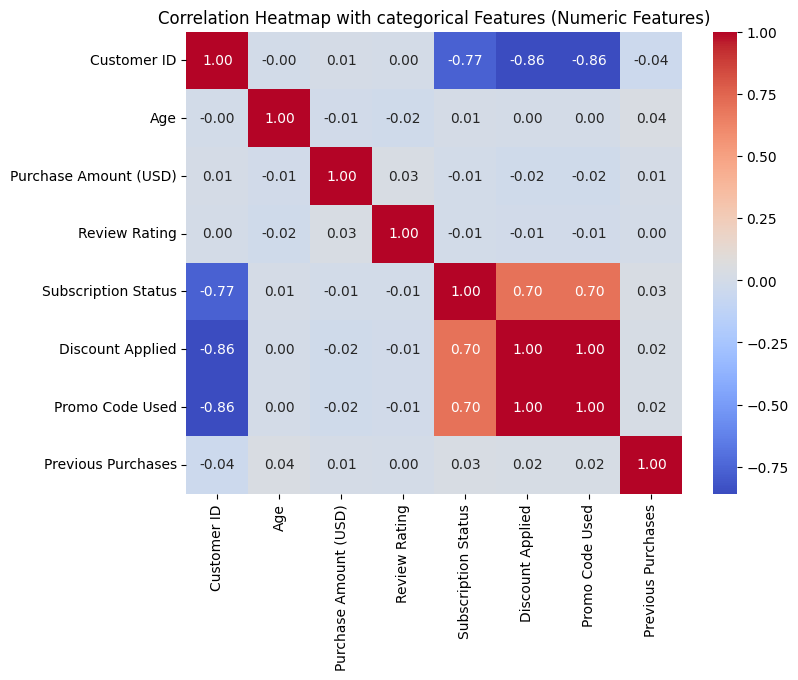

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

num_df = data.select_dtypes(include=[np.number])
corr = num_df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap with categorical Features (Numeric Features)")
plt.show()


In [6]:
#Discount Applied and Promo code used has same similar correlation with subscrition, would like to find out are they same so we can drop either one.
same = (data["Discount Applied"] == data["Promo Code Used"])
same.value_counts()

,count
True,3900


In [7]:
#To find out Promo code used vs subscription status
table = data.groupby(["Promo Code Used", "Subscription Status"]).size().unstack(fill_value=0)
table


Subscription Status,0,1
Promo Code Used,,
0,2223,0
1,624,1053


In [8]:
#Convert to percentage
overall_pct = (table / table.values.sum() * 100).round(1)
overall_pct

Subscription Status,0,1
Promo Code Used,,
0,57.0,0.0
1,16.0,27.0


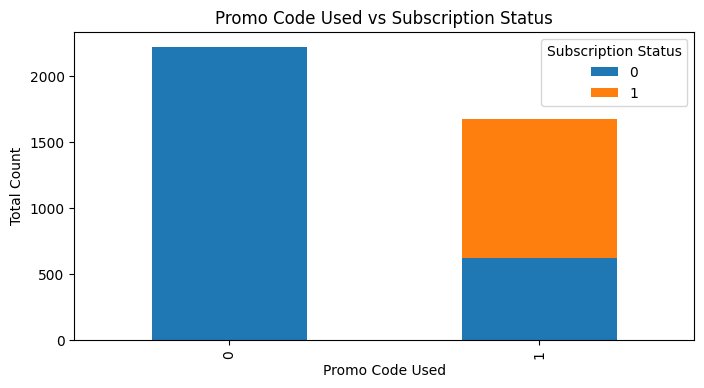

In [9]:
#Plot it
table.plot(kind="bar", stacked=True, figsize=(8,4))
plt.xlabel("Promo Code Used")
plt.title("Promo Code Used vs Subscription Status")
plt.ylabel("Total Count")
plt.show()

"""27% of using promo code will subscribe, 16% of using promo code will not subcribe, where else all no using promo code will not subscribe."""

In [10]:
#To find out which group has highest subcription rate.
def age_group(a):
    if pd.isna(a):
        return "Unknown"
    if a <= 18: return "<=18"
    elif a <= 25: return "19-25"
    elif a <= 35: return "26-35"
    elif a <= 45: return "36-45"
    elif a <= 55: return "46-55"
    elif a <= 65: return "56-65"
    else: return "66+"

data["Age Group"] = data["Age"].apply(age_group)

print(data["Age Group"])

0       46-55
1       19-25
2       46-55
3       19-25
4       36-45
        ...  
3895    36-45
3896    46-55
3897    46-55
3898    36-45
3899    46-55
Name: Age Group, Length: 3900, dtype: object


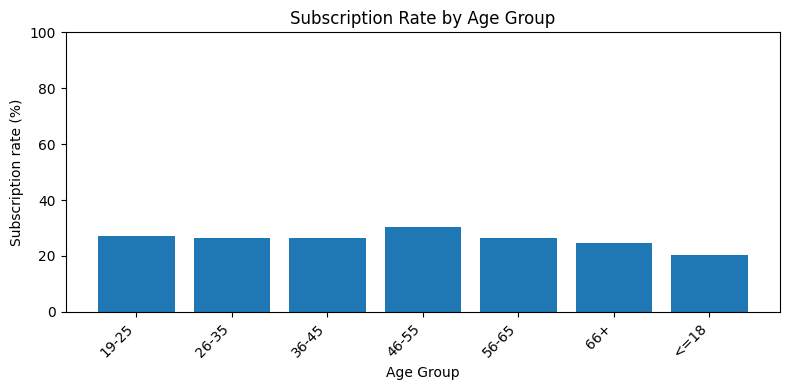

In [11]:
#Plot age group vs subcription rate
# calculate subscription rate by age group
rate = data.groupby("Age Group")["Subscription Status"].mean() * 100

# if Age Group is categorical ordered, this will plot in order
rate = rate.sort_index()

plt.figure(figsize=(8,4))
plt.bar(rate.index.astype(str), rate.values)
plt.ylabel("Subscription rate (%)")
plt.xlabel("Age Group")
plt.title("Subscription Rate by Age Group")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()


In [12]:
data["Age Group"].value_counts().sort_index()

,count
Age Group,
19-25,502
26-35,742
36-45,729
46-55,753
56-65,750
66+,355
<=18,69


"""Age group 46-55 seems slightly higher of subscription rate."""

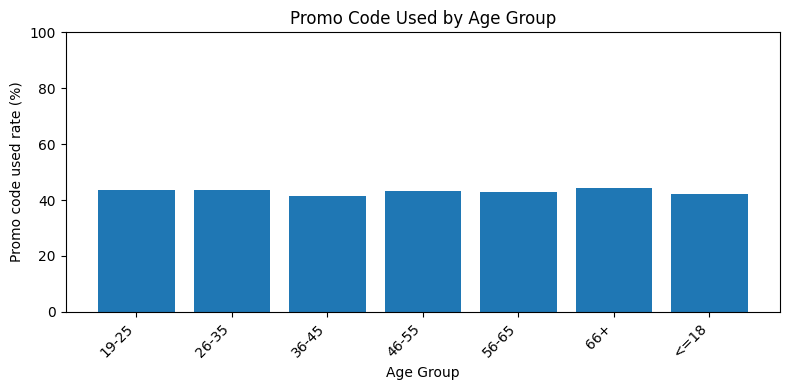

In [13]:
#Plot age group vs promo code
# calculate subscription rate by age group
rate = data.groupby("Age Group")["Promo Code Used"].mean() * 100

# if Age Group is categorical ordered, this will plot in order
rate = rate.sort_index()

plt.figure(figsize=(8,4))
plt.bar(rate.index.astype(str), rate.values)
plt.ylabel("Promo code used rate (%)")
plt.xlabel("Age Group")
plt.title("Promo Code Used by Age Group")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()


All promo code used equally accross each group.


In [14]:
#To find out gender vs subcription rate.
def gender_group(a):
    if pd.isna(a):
        return "Unknown"
    return "Male" if a == "Male" else "Female"


data["Gender_group"] = data["Gender"].apply(gender_group)

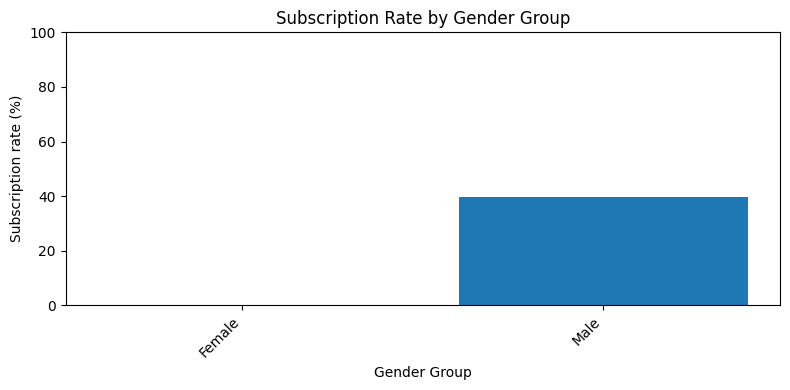

In [15]:
#Plot gender group vs subcription
# calculate subscription rate by age group
rate = data.groupby("Gender_group")["Subscription Status"].mean() * 100

# if Gender Group is categorical ordered, this will plot in order
rate = rate.sort_index()

plt.figure(figsize=(8,4))
plt.bar(rate.index.astype(str), rate.values)
plt.ylabel("Subscription rate (%)")
plt.xlabel("Gender Group")
plt.title("Subscription Rate by Gender Group")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()


The result seem biased because only male subscribed.

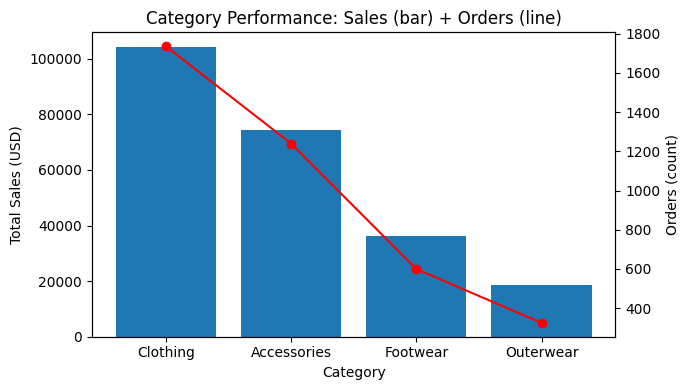

In [16]:
#Which category has the highest selling volume and highest revenue
category_sales = data.groupby("Category").agg(orders=("Category", "count"), total_sales = ("Purchase Amount (USD)", "sum"))
category_sales = category_sales.sort_values(["orders", "total_sales"], ascending = False)
category_sales

fig, ax1 = plt.subplots(figsize=(7,4))
cs = category_sales
# bar = total sales
ax1.bar(cs.index.astype(str), cs["total_sales"])
ax1.set_ylabel("Total Sales (USD)")
ax1.set_xlabel("Category")

# line = orders (second y-axis)
ax2 = ax1.twinx()
ax2.plot(cs.index.astype(str), cs["orders"], marker="o", color = 'r')
ax2.set_ylabel("Orders (count)")

plt.title("Category Performance: Sales (bar) + Orders (line)")
plt.tight_layout()
plt.show()


In [17]:
# total subscribers per category (count of Yes)
sub_count = data.groupby("Category")["Subscription Status"].sum()

# total rows per category
total_rows = data.groupby("Category")["Subscription Status"].size()


In [18]:
# rate (same as mean)
sub_rate = (sub_count / total_rows)*100
sub_rate

,Subscription Status
Category,
Accessories,26.935484
Clothing,26.309729
Footwear,28.547579
Outerwear,28.086420


Each category has no significant impact to the subcription status because they have similar subcritption rate.

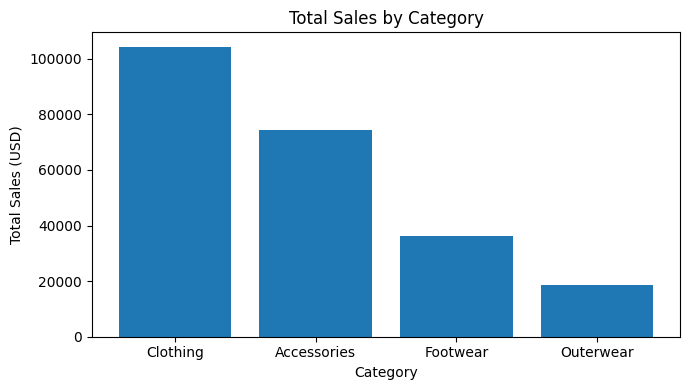

In [19]:
#Plot the category vs Subcription rate and order
plt.figure(figsize=(7,4))
plt.bar(category_sales.index.astype(str), category_sales["total_sales"].values)
plt.ylabel("Total Sales (USD)")
plt.xlabel("Category")
plt.title("Total Sales by Category")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



In [20]:
#Find which season has highest sales volume and revenue and which category
#Find volume vs revenue
season_vol = data.groupby("Season").agg(orders = ("Category", "size"), total_sales = ("Purchase Amount (USD)", "sum"))
season_vol = season_vol.sort_values(["orders","total_sales"], ascending = False)
season_vol


,orders,total_sales
Season,,
Spring,999,58679
Fall,975,60018
Winter,971,58607
Summer,955,55777


In [21]:
#Find which season has highest sales volume and revenue and which category
#Find top category of each season
season_sales = data.groupby(["Season", "Category"]).agg(orders = ("Category", "size"), total_sales = ("Purchase Amount (USD)", "sum"))
season_sales = season_sales.sort_values(["orders","total_sales"], ascending = [False, False]).groupby("Season").head(1)
season_sales


,,orders,total_sales
Season,Category,,
Spring,Clothing,454,27692
Winter,Clothing,448,27274
Fall,Clothing,427,26220
Summer,Clothing,408,23078


In [22]:
# @title
#Which location has the highest volume of buyer.
#Step 1: Find the NaN location
location_sales = data["Location"].isna().sum()
location_sales

#Step 2 : Find the total volume and revenue of the location
Location_sales = data.groupby("Location").agg(orders = ("Location", "size"), total_sales = ("Purchase Amount (USD)", "sum"))
Location_sales = Location_sales.sort_values(["orders", "total_sales"], ascending = False)
Location_sales


,orders,total_sales
Location,,
Montana,96,5784
California,95,5605
Idaho,93,5587
Illinois,92,5617
Alabama,89,5261
Minnesota,88,4977
Nevada,87,5514
New York,87,5257
Nebraska,87,5172


In [23]:
#Plot the bubble geography map. Visualize the large volume location.
import plotly.express as px
state_to_abbrev = {
    "Alabama":"AL","Alaska":"AK","Arizona":"AZ","Arkansas":"AR","California":"CA",
    "Colorado":"CO","Connecticut":"CT","Delaware":"DE","Florida":"FL","Georgia":"GA",
    "Hawaii":"HI","Idaho":"ID","Illinois":"IL","Indiana":"IN","Iowa":"IA","Kansas":"KS",
    "Kentucky":"KY","Louisiana":"LA","Maine":"ME","Maryland":"MD","Massachusetts":"MA",
    "Michigan":"MI","Minnesota":"MN","Mississippi":"MS","Missouri":"MO","Montana":"MT",
    "Nebraska":"NE","Nevada":"NV","New Hampshire":"NH","New Jersey":"NJ","New Mexico":"NM",
    "New York":"NY","North Carolina":"NC","North Dakota":"ND","Ohio":"OH","Oklahoma":"OK",
    "Oregon":"OR","Pennsylvania":"PA","Rhode Island":"RI","South Carolina":"SC","South Dakota":"SD",
    "Tennessee":"TN","Texas":"TX","Utah":"UT","Vermont":"VT","Virginia":"VA","Washington":"WA",
    "West Virginia":"WV","Wisconsin":"WI","Wyoming":"WY","District of Columbia":"DC"
}
# 1) Recreate location_sales correctly (DataFrame)
location_sales = data.groupby("Location").agg(
    orders=("Location", "size"),
    total_sales=("Purchase Amount (USD)", "sum")
).reset_index()


In [24]:
location_sales["scale"] = location_sales["Location"].map(state_to_abbrev)

location_sales

# Create bubble map
fig = px.scatter_geo(location_sales,
    locations="scale",
    locationmode="USA-states",
    scope="usa", hover_name="Location", size="total_sales", hover_data={"orders": True, "total_sales": True}, text = "scale", title="Bubble Map: Total Sales by State")
fig.show()


All areas have equivalent sales volume.

In [25]:
def sub_rate_table(col):
    out = data.groupby(col).agg(
        n=("Subscription Status","size"),
        sub_rate=("Subscription Status","mean")
    )
    out["sub_rate_pct"] = (out["sub_rate"]*100).round(1)
    return out.sort_values(["sub_rate_pct","n"], ascending=[False, False])

for c in ["Age Group","Gender_group","Category","Season","Shipping Type","Payment Method","Location"]:
    display(sub_rate_table(c).head(10))

Promo_sub = pd.crosstab(data["Promo Code Used"], data["Subscription Status"], margins=True)
Promo_sub

,n,sub_rate,sub_rate_pct
Age Group,,,
46-55,753,0.304117,30.4
19-25,502,0.270916,27.1
56-65,750,0.264000,26.4
26-35,742,0.264151,26.4
36-45,729,0.263374,26.3
66+,355,0.247887,24.8
<=18,69,0.202899,20.3


,n,sub_rate,sub_rate_pct
Gender_group,,,
Male,2652,0.397059,39.7
Female,1248,0.000000,0.0


,n,sub_rate,sub_rate_pct
Category,,,
Footwear,599,0.285476,28.5
Outerwear,324,0.280864,28.1
Accessories,1240,0.269355,26.9
Clothing,1737,0.263097,26.3


,n,sub_rate,sub_rate_pct
Season,,,
Summer,955,0.277487,27.7
Fall,975,0.270769,27.1
Spring,999,0.270270,27.0
Winter,971,0.261586,26.2


,n,sub_rate,sub_rate_pct
Shipping Type,,,
Express,646,0.294118,29.4
Store Pickup,650,0.292308,29.2
Standard,654,0.267584,26.8
Free Shipping,675,0.262222,26.2
Next Day Air,648,0.259259,25.9
2-Day Shipping,627,0.244019,24.4


,n,sub_rate,sub_rate_pct
Payment Method,,,
Debit Card,636,0.298742,29.9
Venmo,634,0.274448,27.4
Credit Card,671,0.266766,26.7
PayPal,677,0.265879,26.6
Cash,670,0.258209,25.8
Bank Transfer,612,0.256536,25.7


,n,sub_rate,sub_rate_pct
Location,,,
South Carolina,76,0.355263,35.5
West Virginia,81,0.345679,34.6
Nevada,87,0.344828,34.5
Missouri,81,0.333333,33.3
Oklahoma,75,0.333333,33.3
Kentucky,79,0.329114,32.9
Delaware,86,0.325581,32.6
Massachusetts,72,0.319444,31.9
Virginia,77,0.311688,31.2


Subscription Status,0,1,All
Promo Code Used,,,
0,2223,0,2223
1,624,1053,1677
All,2847,1053,3900


In [26]:
#Convert categorical column with one-hot encoding
X = pd.get_dummies(data.drop(["Subscription Status", "Customer ID"],axis=1), drop_first = True)
y = data['Subscription Status']

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)
ypred = model.predict(X_test)


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.94      0.85      0.89       569
           1       0.67      0.84      0.75       211

    accuracy                           0.85       780
   macro avg       0.81      0.85      0.82       780
weighted avg       0.87      0.85      0.85       780

[[483  86]
 [ 33 178]]


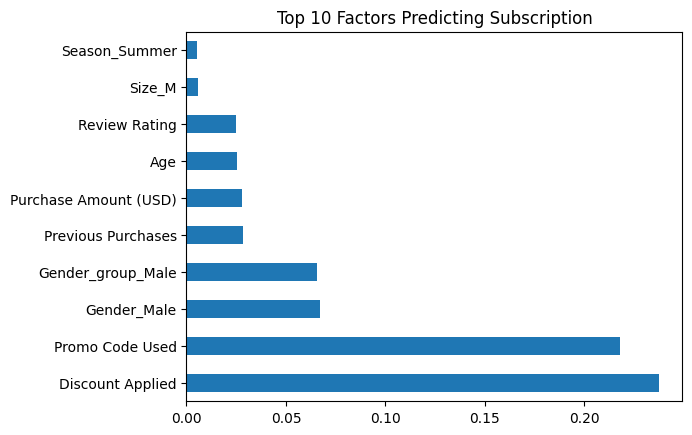

In [27]:
from sklearn.metrics import classification_report, confusion_matrix

# 1. Print the text-based report
print("--- Classification Report ---")
print(classification_report(y_test, ypred))

# 2. Print the Confusion Matrix (Visual check of errors)
# print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, ypred))

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh')
plt.title("Top 10 Factors Predicting Subscription")
plt.show()
